# Задача 4. Выбор ценовой стратегии для AI-сервиса по созданию контента

## Цель работы

Необходимо сравнить четыре ценовые стратегии для сервиса «AI-Копирайтер» и определить, какая стратегия обеспечивает наиболее эффективные экономические показатели.

В рамках работы необходимо:

1. рассчитать ключевые показатели ARPU, LTV и LTV/CAC;
2. спрогнозировать финансовый результат на 3 года;
3. рассчитать NPV для каждой стратегии;
4. провести анализ чувствительности к изменению конверсии, Churn Rate и CAC;
5. выбрать ценовую стратегию;
6. разработать план её внедрения;
7. определить ключевые показатели мониторинга;
8. проанализировать риски и меры их снижения.

## 1. Исходные данные

### Данные о рынке

| Показатель | Значение |
|---|---:|
| Потенциальный рынок в России | 500 000 пользователей |
| Темп роста рынка | 25% в год |
| Начальная база пользователей | 1 000 |

### Затраты

| Показатель | Значение |
|---|---:|
| Затраты на разработку | 15 000 000 руб. |
| Поддержание и облачные услуги | 2 000 000 руб./мес. |
| CAC — реклама | 1 500 руб. |
| CAC — контент-маркетинг и SEO | 800 руб. |
| CAC — виральный рост | 100 руб. |

### Параметры ценовых стратегий

| Стратегия | Цена | Конверсия в платных | Churn |
|---|---:|---:|---:|
| Freemium | 2 000 руб./мес. | 2% | 8% |
| Подписка | 1 500 руб./мес. | 20% | 5% |
| Динамическая | 500–2 000 руб./мес. | 15% | 6% |
| Персонализированная | 300–5 000 руб./мес. | 12% | 4% |

### Дополнительные параметры

| Показатель | Значение |
|---|---:|
| Ставка дисконтирования | 12% годовых |
| Горизонт планирования | 3 года |

## 2. Допущения для расчёта

В условии задачи некоторые параметры заданы в виде диапазонов или не имеют точного распределения, поэтому для построения единой расчётной модели принимаются следующие допущения.

### 1. Цена динамической стратегии

Для стратегии «Динамическая» задан диапазон от 500 до 2 000 руб./мес.

Для расчёта используется средняя цена диапазона:

$$
P_{динамическая}=\frac{500+2000}{2}=1250\text{ руб./мес.}
$$

### 2. Цена персонализированной стратегии

Для стратегии «Персонализированная» задан диапазон от 300 до 5 000 руб./мес.

Используем среднюю цену:

$$
P_{персонализированная}=\frac{300+5000}{2}=2650\text{ руб./мес.}
$$

### 3. Средний CAC

В условии приведены три канала привлечения пользователей:

- реклама — 1 500 руб.;
- контент-маркетинг и SEO — 800 руб.;
- виральный рост — 100 руб.

Доли пользователей, привлечённых через каждый канал, не заданы. Поэтому для общей финансовой модели используется среднее значение CAC:

$$
CAC_{avg}=
\frac{1500+800+100}{3}
=800\text{ руб.}
$$

При этом отдельно будет рассчитано соотношение LTV/CAC для каждого канала, как требуется в задании.

### 4. Рост пользовательской базы

Начальная база в Год 0 составляет 1 000 пользователей.

Согласно условию:

- Год 1 — прирост 100%;
- Год 2 — прирост 50%;
- Год 3 — прирост 20%.

Таким образом, количество пользователей рассчитывается последовательно от предыдущего года.

### 5. Затраты на разработку

Затраты на разработку в размере 15 млн руб. рассматриваются как первоначальные инвестиции в момент запуска проекта.

При расчёте NPV они учитываются в момент 0 и поэтому не дисконтируются.

### 6. Churn Rate

Churn используется при расчёте среднего срока жизни клиента и LTV.

В прогнозе пользовательской базы Churn отдельно не вычитается, поскольку количество пользователей по годам уже задано условием задачи. Это позволяет избежать двойного учёта оттока пользователей.

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Данные о рынке
market_size = 500_000
market_growth = 0.25
initial_users = 1_000

# Затраты
development_cost = 15_000_000
monthly_support_cost = 2_000_000

# CAC по каналам привлечения
cac_advertising = 1_500
cac_content = 800
cac_viral = 100

# Финансовые параметры
discount_rate = 0.12
years = 3

# Параметры ценовых стратегий
strategies = {
    "Freemium": {
        "price": 2_000,
        "conversion": 0.02,
        "churn": 0.08
    },
    
    "Подписка": {
        "price": 1_500,
        "conversion": 0.20,
        "churn": 0.05
    },
    
    "Динамическая": {
        "price": 1_250,  # Средняя цена диапазона 500–2 000
        "conversion": 0.15,
        "churn": 0.06
    },
    
    "Персонализированная": {
        "price": 2_650,  # Средняя цена диапазона 300–5 000
        "conversion": 0.12,
        "churn": 0.04
    }
}

## 3. Расчёт ARPU

ARPU (Average Revenue Per User) показывает средний доход, который приходится на одного пользователя.

В данной задаче необходимо учитывать конверсию пользователей в платных клиентов.

Поэтому используем формулу:

$$
ARPU=P\times C
$$

где:

- $ARPU$ — средний доход на одного пользователя в месяц, руб.;
- $P$ — цена тарифа в месяц, руб.;
- $C$ — конверсия пользователей в платных клиентов.

Например, для стратегии Freemium:

$$
ARPU=2000\times0{,}02=40\text{ руб./мес.}
$$

Это означает, что в среднем один пользователь общей базы приносит сервису 40 руб. дохода в месяц с учётом того, что платными становятся только 2% пользователей.

In [3]:
# Рассчитываем ARPU для каждой стратегии

for name, data in strategies.items():
    data["arpu"] = data["price"] * data["conversion"]

    print(
        f"{name}: "
        f"ARPU = {data['arpu']:.2f} руб./мес."
    )

Freemium: ARPU = 40.00 руб./мес.
Подписка: ARPU = 300.00 руб./мес.
Динамическая: ARPU = 187.50 руб./мес.
Персонализированная: ARPU = 318.00 руб./мес.


### Результаты расчёта ARPU

Полученные значения:

| Стратегия | Цена, руб./мес. | Конверсия | ARPU, руб./мес. |
|---|---:|---:|---:|
| Freemium | 2 000 | 2% | 40 |
| Подписка | 1 500 | 20% | 300 |
| Динамическая | 1 250 | 15% | 187,5 |
| Персонализированная | 2 650 | 12% | 318 |

На основании расчёта можно увидеть, что наиболее высокий ARPU имеет персонализированная стратегия — 318 руб. на пользователя в месяц.

## 4. Расчёт среднего срока жизни клиента

Средний срок жизни клиента показывает, сколько месяцев в среднем пользователь остаётся клиентом сервиса.

Согласно условию задачи, используется формула:

$$
Lifetime=\frac{1}{Churn}
$$

где:

- $Lifetime$ — средний срок жизни клиента, мес.;
- $Churn$ — коэффициент оттока клиентов.

Churn необходимо записывать в виде десятичной дроби.

Например, для стратегии «Подписка»:

$$
Churn=5\%=0{,}05
$$

Тогда:

$$
Lifetime=\frac{1}{0{,}05}=20\text{ месяцев}
$$

In [4]:
# Рассчитываем средний срок жизни клиента

for name, data in strategies.items():
    data["lifetime"] = 1 / data["churn"]

    print(
        f"{name}: "
        f"средний срок жизни = "
        f"{data['lifetime']:.1f} мес."
    )

Freemium: средний срок жизни = 12.5 мес.
Подписка: средний срок жизни = 20.0 мес.
Динамическая: средний срок жизни = 16.7 мес.
Персонализированная: средний срок жизни = 25.0 мес.


### Результаты расчёта среднего срока жизни

| Стратегия | Churn | Средний срок жизни |
|---|---:|---:|
| Freemium | 8% | 12,5 мес. |
| Подписка | 5% | 20 мес. |
| Динамическая | 6% | 16,7 мес. |
| Персонализированная | 4% | 25 мес. |

Наибольший средний срок жизни клиента получается у персонализированной стратегии — 25 месяцев. Это связано с самым низким Churn Rate среди рассматриваемых стратегий.

## 5. Расчёт LTV

LTV (Lifetime Value) показывает совокупную ценность клиента за весь период его взаимодействия с сервисом.

Согласно условию задачи:

$$
LTV=\frac{ARPU}{Churn}
$$

где:

- $LTV$ — пожизненная ценность клиента, руб.;
- $ARPU$ — средний доход на пользователя в месяц;
- $Churn$ — коэффициент оттока клиентов.

Например, для стратегии «Подписка»:

$$
LTV=\frac{300}{0{,}05}=6000\text{ руб.}
$$

Таким образом, расчётная ценность одного клиента за весь период его взаимодействия с сервисом составляет 6 000 руб.

In [5]:
# Рассчитываем LTV для каждой стратегии

for name, data in strategies.items():
    data["ltv"] = data["arpu"] / data["churn"]

    print(
        f"{name}: "
        f"LTV = {data['ltv']:.2f} руб."
    )

Freemium: LTV = 500.00 руб.
Подписка: LTV = 6000.00 руб.
Динамическая: LTV = 3125.00 руб.
Персонализированная: LTV = 7950.00 руб.


### Результаты расчёта LTV

| Стратегия | ARPU, руб./мес. | Churn | LTV, руб. |
|---|---:|---:|---:|
| Freemium | 40 | 8% | 500 |
| Подписка | 300 | 5% | 6 000 |
| Динамическая | 187,5 | 6% | 3 125 |
| Персонализированная | 318 | 4% | 7 950 |

Наибольшее значение LTV имеет персонализированная стратегия — 7 950 руб.

Высокий LTV в данном случае объясняется сочетанием относительно высокого ARPU и низкого Churn Rate.

## 6. Расчёт показателя LTV/CAC

LTV/CAC показывает соотношение ценности привлечённого клиента и затрат на его привлечение.

Формула:

$$
LTV/CAC=\frac{LTV}{CAC}
$$

где:

- $LTV$ — совокупная ценность клиента за весь период взаимодействия с сервисом, руб.;
- $CAC$ — стоимость привлечения одного клиента, руб.

В условии задачи указаны три канала привлечения:

- реклама — 1 500 руб.;
- контент-маркетинг и SEO — 800 руб.;
- вирусный рост — 100 руб.

Рассчитаем показатель LTV/CAC отдельно для каждого канала и каждой ценовой стратегии.

In [6]:
# Указываем CAC для каждого канала привлечения
cac_channels = {
    "Реклама": cac_advertising,
    "Контент-маркетинг + SEO": cac_content,
    "Вирусный рост": cac_viral
}

# Создаём таблицу результатов
ltv_cac_results = []

for strategy_name, data in strategies.items():
    for channel_name, cac in cac_channels.items():

        # Рассчитываем LTV/CAC
        ltv_cac = data["ltv"] / cac

        ltv_cac_results.append({
            "Стратегия": strategy_name,
            "Канал": channel_name,
            "CAC, руб.": cac,
            "LTV, руб.": data["ltv"],
            "LTV/CAC": ltv_cac
        })

ltv_cac_df = pd.DataFrame(ltv_cac_results)

ltv_cac_df

,Стратегия,Канал,"CAC, руб.","LTV, руб.",LTV/CAC
0,Freemium,Реклама,1500,500.0,0.333333
1,Freemium,Контент-маркетинг + SEO,800,500.0,0.625000
2,Freemium,Вирусный рост,100,500.0,5.000000
3,Подписка,Реклама,1500,6000.0,4.000000
4,Подписка,Контент-маркетинг + SEO,800,6000.0,7.500000
5,Подписка,Вирусный рост,100,6000.0,60.000000
6,Динамическая,Реклама,1500,3125.0,2.083333
7,Динамическая,Контент-маркетинг + SEO,800,3125.0,3.906250
8,Динамическая,Вирусный рост,100,3125.0,31.250000
9,Персонализированная,Реклама,1500,7950.0,5.300000


### Результаты расчёта LTV/CAC

Полученные значения показывают, во сколько раз совокупная ценность клиента превышает стоимость его привлечения.

Например, для стратегии «Подписка» при использовании контент-маркетинга:

$$
LTV/CAC=\frac{6000}{800}=7{,}5
$$

Это означает, что рассчитанный LTV в 7,5 раза превышает CAC данного канала.

Наиболее высокие значения LTV/CAC получаются при использовании вирусного роста, поскольку стоимость привлечения пользователя через этот канал минимальна.

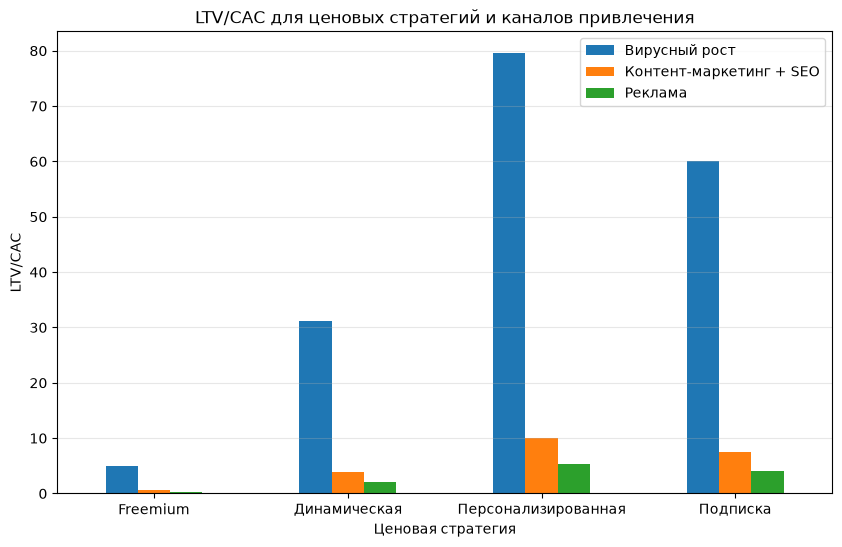

In [7]:
# Преобразуем таблицу для построения графика
ltv_cac_pivot = ltv_cac_df.pivot(
    index="Стратегия",
    columns="Канал",
    values="LTV/CAC"
)

# Строим столбчатую диаграмму
ltv_cac_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("LTV/CAC для ценовых стратегий и каналов привлечения")
plt.xlabel("Ценовая стратегия")
plt.ylabel("LTV/CAC")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## 7. Прогноз количества пользователей

Для оценки финансового результата необходимо спрогнозировать количество пользователей сервиса на три года.

В условии задачи задана начальная пользовательская база:

$$
N_0=1000
$$

Также заданы темпы роста:

- в первый год — 100%;
- во второй год — 50%;
- в третий год — 20%.

Количество пользователей каждого следующего года рассчитывается относительно предыдущего года:

$$
N_t=N_{t-1}(1+g_t)
$$

где:

- $N_t$ — количество пользователей в текущем году;
- $N_{t-1}$ — количество пользователей в предыдущем году;
- $g_t$ — темп роста пользовательской базы.

Таким образом:

$$
N_1=1000\times(1+1)=2000
$$

$$
N_2=2000\times(1+0{,}5)=3000
$$

$$
N_3=3000\times(1+0{,}2)=3600
$$

In [8]:
# Начальная пользовательская база
users = [initial_users]

# Темпы роста по годам
growth_rates = [1.00, 0.50, 0.20]

# Последовательно рассчитываем количество пользователей
for growth in growth_rates:
    new_users = users[-1] * (1 + growth)
    users.append(new_users)

# Создаём таблицу
users_df = pd.DataFrame({
    "Год": [0, 1, 2, 3],
    "Количество пользователей": users
})

users_df

,Год,Количество пользователей
0,0,1000.0
1,1,2000.0
2,2,3000.0
3,3,3600.0


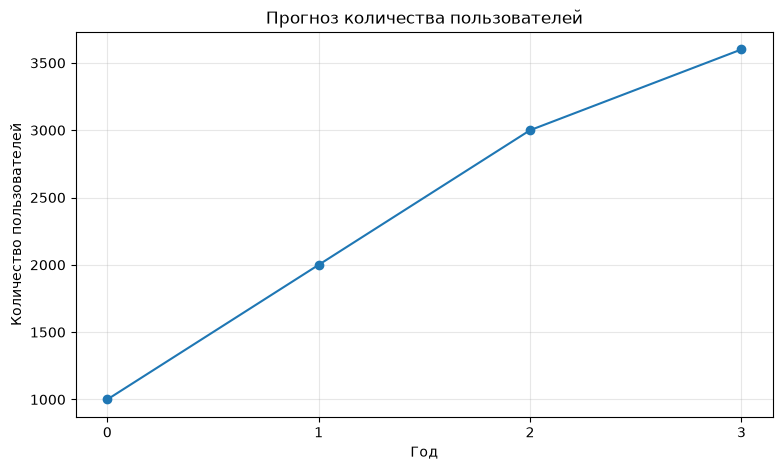

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    users_df["Год"],
    users_df["Количество пользователей"],
    marker="o"
)

plt.title("Прогноз количества пользователей")
plt.xlabel("Год")
plt.ylabel("Количество пользователей")
plt.xticks([0, 1, 2, 3])
plt.grid(True, alpha=0.3)

plt.show()

Таким образом, за три года пользовательская база увеличивается с 1 000 до 3 600 пользователей.

## 8. Прогноз выручки

Для расчёта годовой выручки используем рассчитанный ранее показатель ARPU.

ARPU показывает среднюю месячную выручку на одного пользователя с учётом конверсии в платную версию.

Годовая выручка рассчитывается по формуле:

$$
Revenue_t=N_t\times ARPU\times12
$$

где:

- $Revenue_t$ — выручка за год;
- $N_t$ — количество пользователей в соответствующем году;
- $ARPU$ — средняя выручка на одного пользователя в месяц;
- $12$ — количество месяцев в году.

Расчёт выполняется отдельно для каждой ценовой стратегии.

In [10]:
# Создаём список для результатов расчёта
revenue_results = []

for strategy_name, data in strategies.items():

    # Берём количество пользователей за 1–3 годы
    for year, user_count in zip(range(1, 4), users[1:]):

        # Рассчитываем годовую выручку
        revenue = user_count * data["arpu"] * 12

        revenue_results.append({
            "Стратегия": strategy_name,
            "Год": year,
            "Пользователи": user_count,
            "ARPU, руб./мес.": data["arpu"],
            "Выручка, руб.": revenue
        })

revenue_df = pd.DataFrame(revenue_results)

revenue_df

,Стратегия,Год,Пользователи,"ARPU, руб./мес.","Выручка, руб."
0,Freemium,1,2000.0,40.0,960000.0
1,Freemium,2,3000.0,40.0,1440000.0
2,Freemium,3,3600.0,40.0,1728000.0
3,Подписка,1,2000.0,300.0,7200000.0
4,Подписка,2,3000.0,300.0,10800000.0
5,Подписка,3,3600.0,300.0,12960000.0
6,Динамическая,1,2000.0,187.5,4500000.0
7,Динамическая,2,3000.0,187.5,6750000.0
8,Динамическая,3,3600.0,187.5,8100000.0
9,Персонализированная,1,2000.0,318.0,7632000.0


### Вывод

Годовая выручка увеличивается вместе с ростом пользовательской базы.

При этом стратегии с более высоким ARPU формируют большую выручку при одинаковом количестве пользователей.

## 9. Расчёт затрат на привлечение пользователей

В условии указаны значения CAC для трёх каналов привлечения:

- реклама — 1 500 руб.;
- контент-маркетинг и SEO — 800 руб.;
- вирусный рост — 100 руб.

Для общего финансового прогноза используем среднее значение CAC:

$$
CAC_{avg}=
\frac{1500+800+100}{3}
=800\text{ руб.}
$$

Количество новых пользователей рассчитывается как разница между пользовательскими базами соседних лет.

Таким образом:

- в первый год привлечено 1 000 новых пользователей;
- во второй год — 1 000 новых пользователей;
- в третий год — 600 новых пользователей.

Затраты на привлечение рассчитываются:

$$
CAC\ Cost_t=NewUsers_t\times CAC_{avg}
$$

Использование среднего CAC является упрощением, поскольку в условии не указано, какая доля пользователей приходит через каждый канал.

In [11]:
# Рассчитываем средний CAC
average_cac = (
    cac_advertising +
    cac_content +
    cac_viral
) / 3

# Количество новых пользователей по годам
new_users = [
    users[1] - users[0],
    users[2] - users[1],
    users[3] - users[2]
]

# Рассчитываем затраты на привлечение
cac_costs = [
    new_users_count * average_cac
    for new_users_count in new_users
]

cac_df = pd.DataFrame({
    "Год": [1, 2, 3],
    "Новые пользователи": new_users,
    "Средний CAC, руб.": [average_cac] * 3,
    "Затраты на привлечение, руб.": cac_costs
})

cac_df

,Год,Новые пользователи,"Средний CAC, руб.","Затраты на привлечение, руб."
0,1,1000.0,800.0,800000.0
1,2,1000.0,800.0,800000.0
2,3,600.0,800.0,480000.0


## 10. Прогноз прибыли на 3 года

Ежемесячные затраты на поддержку и облачные сервисы составляют 2 000 000 руб.

Годовые операционные затраты:

$$
C_{operating}=2\,000\,000\times12
=24\,000\,000\text{ руб.}
$$

Годовая прибыль рассчитывается как:

$$
Profit_t=
Revenue_t-C_{operating}-CAC\ Cost_t
$$

где:

- $Profit_t$ — прибыль за год;
- $Revenue_t$ — годовая выручка;
- $C_{operating}$ — годовые операционные затраты;
- $CAC\ Cost_t$ — затраты на привлечение новых пользователей.

Первоначальные затраты на разработку в размере 15 000 000 руб. в этот расчёт не включаем. Они будут учтены отдельно при расчёте NPV как первоначальные инвестиции.

In [12]:
# Рассчитываем годовые операционные расходы
annual_operating_cost = monthly_support_cost * 12

profit_results = []

for strategy_name, data in strategies.items():

    # Получаем выручку данной стратегии
    strategy_revenue = revenue_df[
        revenue_df["Стратегия"] == strategy_name
    ].sort_values("Год")

    for _, row in strategy_revenue.iterrows():

        year = int(row["Год"])
        revenue = row["Выручка, руб."]

        # CAC-затраты соответствующего года
        cac_cost = cac_costs[year - 1]

        # Рассчитываем прибыль
        profit = (
            revenue
            - annual_operating_cost
            - cac_cost
        )

        profit_results.append({
            "Стратегия": strategy_name,
            "Год": year,
            "Выручка, руб.": revenue,
            "Операционные расходы, руб.": annual_operating_cost,
            "CAC-затраты, руб.": cac_cost,
            "Прибыль, руб.": profit
        })

profit_df = pd.DataFrame(profit_results)

profit_df

,Стратегия,Год,"Выручка, руб.","Операционные расходы, руб.","CAC-затраты, руб.","Прибыль, руб."
0,Freemium,1,960000.0,24000000,800000.0,-23840000.0
1,Freemium,2,1440000.0,24000000,800000.0,-23360000.0
2,Freemium,3,1728000.0,24000000,480000.0,-22752000.0
3,Подписка,1,7200000.0,24000000,800000.0,-17600000.0
4,Подписка,2,10800000.0,24000000,800000.0,-14000000.0
5,Подписка,3,12960000.0,24000000,480000.0,-11520000.0
6,Динамическая,1,4500000.0,24000000,800000.0,-20300000.0
7,Динамическая,2,6750000.0,24000000,800000.0,-18050000.0
8,Динамическая,3,8100000.0,24000000,480000.0,-16380000.0
9,Персонализированная,1,7632000.0,24000000,800000.0,-17168000.0


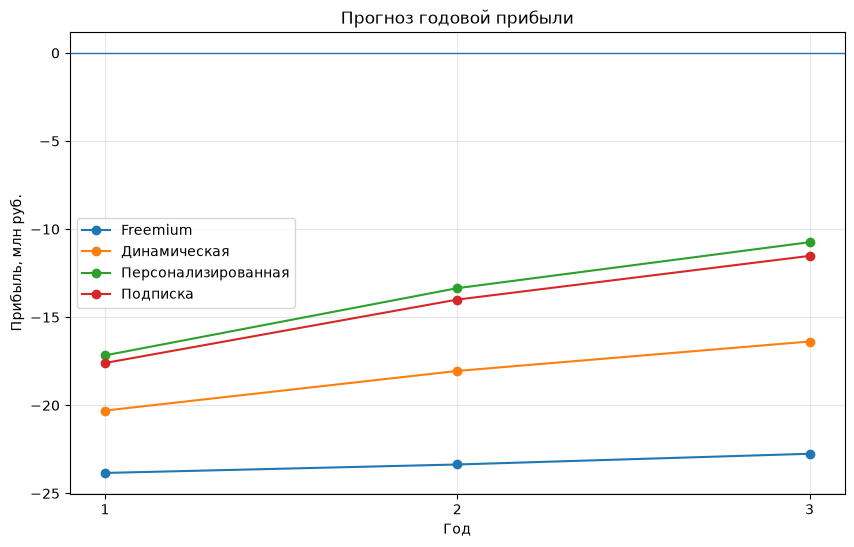

In [13]:
# Подготавливаем данные для графика
profit_pivot = profit_df.pivot(
    index="Год",
    columns="Стратегия",
    values="Прибыль, руб."
)

plt.figure(figsize=(10, 6))

for strategy_name in profit_pivot.columns:
    plt.plot(
        profit_pivot.index,
        profit_pivot[strategy_name] / 1_000_000,
        marker="o",
        label=strategy_name
    )

# Добавляем линию безубыточности
plt.axhline(0, linewidth=1)

plt.title("Прогноз годовой прибыли")
plt.xlabel("Год")
plt.ylabel("Прибыль, млн руб.")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Вывод

При заданных исходных данных все четыре стратегии показывают отрицательную прибыль в течение первых трёх лет.

Основной причиной являются высокие операционные расходы на поддержку и облачную инфраструктуру — 24 млн руб. в год.

Далее необходимо рассчитать NPV, чтобы учесть первоначальные инвестиции и изменение стоимости денежных потоков во времени.

## 11. Расчёт NPV

В задании необходимо рассчитать NPV проекта на горизонте трёх лет.

Ставка дисконтирования:

$$
r=12\%
$$

NPV рассчитывается с учётом первоначальных инвестиций и денежных потоков последующих лет:

$$
NPV=
CF_0+
\frac{CF_1}{(1+r)^1}+
\frac{CF_2}{(1+r)^2}+
\frac{CF_3}{(1+r)^3}
$$

где:

- $CF_0$ — первоначальный денежный поток;
- $CF_t$ — денежный поток соответствующего года;
- $r$ — ставка дисконтирования;
- $t$ — номер года.

Затраты на разработку составляют 15 000 000 руб., поэтому:

$$
CF_0=-15\,000\,000
$$

Для первого, второго и третьего года используем рассчитанную ранее прибыль:

$$
CF_t=Profit_t
$$

In [14]:
# Рассчитываем NPV для каждой стратегии
npv_results = []

for strategy_name in strategies.keys():

    # Получаем прибыли стратегии за 3 года
    strategy_profits = profit_df[
        profit_df["Стратегия"] == strategy_name
    ].sort_values("Год")["Прибыль, руб."].tolist()

    # Первоначальные инвестиции
    npv = -development_cost

    # Добавляем дисконтированные денежные потоки
    for year, cash_flow in enumerate(strategy_profits, start=1):
        npv += cash_flow / ((1 + discount_rate) ** year)

    npv_results.append({
        "Стратегия": strategy_name,
        "NPV, руб.": npv
    })

npv_df = pd.DataFrame(npv_results)

npv_df

,Стратегия,"NPV, руб."
0,Freemium,-7.110259e+07
1,Подписка,-5.007471e+07
2,Динамическая,-5.917331e+07
3,Персонализированная,-4.861893e+07


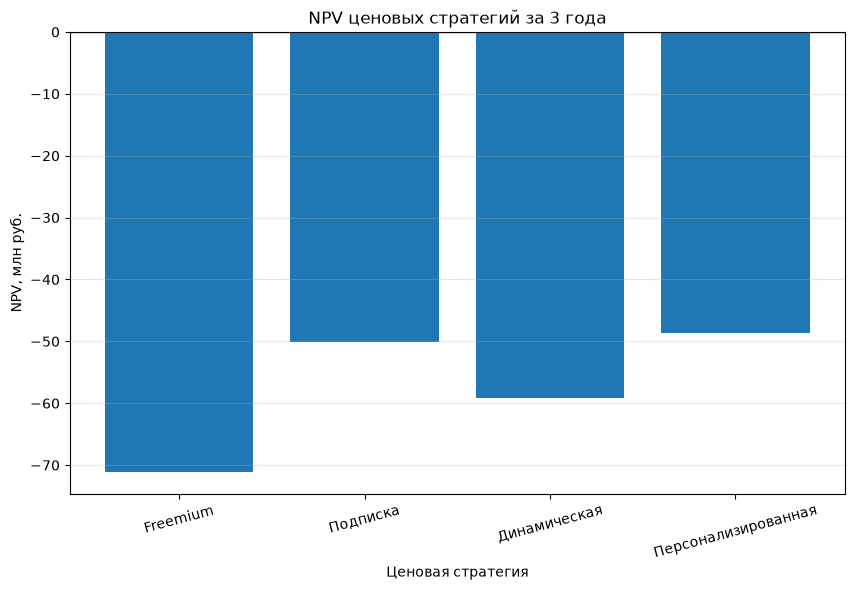

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    npv_df["Стратегия"],
    npv_df["NPV, руб."] / 1_000_000
)

plt.axhline(0, linewidth=1)

plt.title("NPV ценовых стратегий за 3 года")
plt.xlabel("Ценовая стратегия")
plt.ylabel("NPV, млн руб.")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Вывод по NPV

При заданных исходных условиях NPV всех четырёх стратегий является отрицательным.

Это означает, что за рассматриваемые три года проект не успевает компенсировать первоначальные инвестиции и текущие расходы.

При этом стратегии отличаются по величине NPV. Поэтому при выборе варианта ценообразования необходимо учитывать не только цену и LTV/CAC, но и общий финансовый результат проекта.

## 12. Сводное сравнение ценовых стратегий

На предыдущих этапах были рассчитаны основные показатели каждой ценовой стратегии:

- цена;
- конверсия;
- Churn;
- ARPU;
- Lifetime;
- LTV;
- LTV/CAC;
- NPV.

Объединим их в одну таблицу для итогового сравнения.

Для показателя LTV/CAC будем использовать средний CAC, рассчитанный ранее:

$$
CAC_{avg}=800\text{ руб.}
$$

Это позволяет сравнить стратегии между собой при одинаковом условии привлечения пользователей.

In [16]:
# Формируем сводную таблицу по всем стратегиям

summary_results = []

for strategy_name, data in strategies.items():

    # LTV/CAC при среднем CAC
    average_ltv_cac = data["ltv"] / average_cac

    # Находим NPV данной стратегии
    strategy_npv = npv_df.loc[
        npv_df["Стратегия"] == strategy_name,
        "NPV, руб."
    ].iloc[0]

    summary_results.append({
        "Стратегия": strategy_name,
        "Цена, руб./мес.": data["price"],
        "Конверсия, %": data["conversion"] * 100,
        "Churn, %": data["churn"] * 100,
        "ARPU, руб./мес.": data["arpu"],
        "Lifetime, мес.": data["lifetime"],
        "LTV, руб.": data["ltv"],
        "LTV/CAC": average_ltv_cac,
        "NPV, млн руб.": strategy_npv / 1_000_000
    })

summary_df = pd.DataFrame(summary_results)

summary_df.round(2)

,Стратегия,"Цена, руб./мес.","Конверсия, %","Churn, %","ARPU, руб./мес.","Lifetime, мес.","LTV, руб.",LTV/CAC,"NPV, млн руб."
0,Freemium,2000,2.0,8.0,40.0,12.50,500.0,0.62,-71.10
1,Подписка,1500,20.0,5.0,300.0,20.00,6000.0,7.50,-50.07
2,Динамическая,1250,15.0,6.0,187.5,16.67,3125.0,3.91,-59.17
3,Персонализированная,2650,12.0,4.0,318.0,25.00,7950.0,9.94,-48.62


Из таблицы видно, что персонализированная стратегия имеет наибольшие значения ARPU, Lifetime, LTV и LTV/CAC среди рассмотренных вариантов.

При этом NPV всех стратегий остаётся отрицательным на заданном трёхлетнем горизонте.

## 13. Сравнение LTV

Сравним рассчитанный показатель LTV для всех четырёх ценовых стратегий.

Это позволяет наглядно увидеть различия в совокупной ценности клиента для бизнеса.

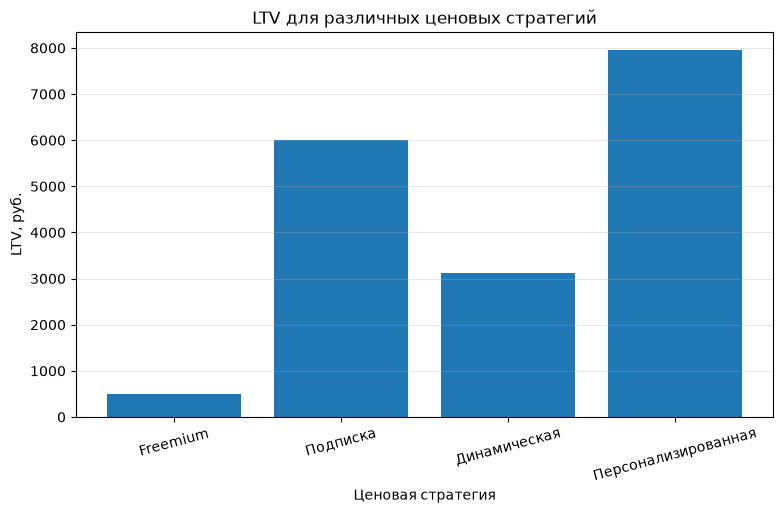

In [17]:
# Строим график LTV

plt.figure(figsize=(9, 5))

plt.bar(
    summary_df["Стратегия"],
    summary_df["LTV, руб."]
)

plt.title("LTV для различных ценовых стратегий")
plt.xlabel("Ценовая стратегия")
plt.ylabel("LTV, руб.")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 14. Анализ чувствительности

Для оценки устойчивости ценовых стратегий проведём анализ чувствительности.

В задании необходимо исследовать изменение трёх параметров:

- конверсии;
- Churn;
- CAC.

Каждый параметр изменяется на ±30% относительно базового значения.

В качестве результирующего показателя будем использовать LTV/CAC.

Это связано с тем, что:

$$
ARPU=Price\times Conversion
$$

а:

$$
LTV=\frac{ARPU}{Churn}
$$

и:

$$
LTV/CAC=\frac{LTV}{CAC}
$$

Следовательно, изменение конверсии, Churn и CAC непосредственно влияет на экономику привлечения клиента.

В каждом сценарии изменяется только один параметр, а остальные остаются на базовом уровне.

In [18]:
# Создаём таблицу для результатов анализа чувствительности

sensitivity_results = []

for strategy_name, data in strategies.items():

    # Базовые значения стратегии
    base_price = data["price"]
    base_conversion = data["conversion"]
    base_churn = data["churn"]
    base_ltv = data["ltv"]

    # ==========================================
    # Изменение конверсии
    # ==========================================

    for change in [-0.30, 0.30]:

        # Меняем только конверсию
        new_conversion = base_conversion * (1 + change)

        # Новый ARPU
        new_arpu = base_price * new_conversion

        # Новый LTV
        new_ltv = new_arpu / base_churn

        # Новый LTV/CAC
        new_ratio = new_ltv / average_cac

        sensitivity_results.append({
            "Стратегия": strategy_name,
            "Параметр": "Конверсия",
            "Изменение": f"{change * 100:+.0f}%",
            "LTV/CAC": new_ratio
        })

    # ==========================================
    # Изменение Churn
    # ==========================================

    for change in [-0.30, 0.30]:

        # Меняем только Churn
        new_churn = base_churn * (1 + change)

        # Новый LTV
        new_ltv = data["arpu"] / new_churn

        # Новый LTV/CAC
        new_ratio = new_ltv / average_cac

        sensitivity_results.append({
            "Стратегия": strategy_name,
            "Параметр": "Churn",
            "Изменение": f"{change * 100:+.0f}%",
            "LTV/CAC": new_ratio
        })

    # ==========================================
    # Изменение CAC
    # ==========================================

    for change in [-0.30, 0.30]:

        # Меняем только CAC
        new_cac = average_cac * (1 + change)

        # Новый LTV/CAC
        new_ratio = base_ltv / new_cac

        sensitivity_results.append({
            "Стратегия": strategy_name,
            "Параметр": "CAC",
            "Изменение": f"{change * 100:+.0f}%",
            "LTV/CAC": new_ratio
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df.round(2)

,Стратегия,Параметр,Изменение,LTV/CAC
0,Freemium,Конверсия,-30%,0.44
1,Freemium,Конверсия,+30%,0.81
2,Freemium,Churn,-30%,0.89
3,Freemium,Churn,+30%,0.48
4,Freemium,CAC,-30%,0.89
5,Freemium,CAC,+30%,0.48
6,Подписка,Конверсия,-30%,5.25
7,Подписка,Конверсия,+30%,9.75
8,Подписка,Churn,-30%,10.71
9,Подписка,Churn,+30%,5.77


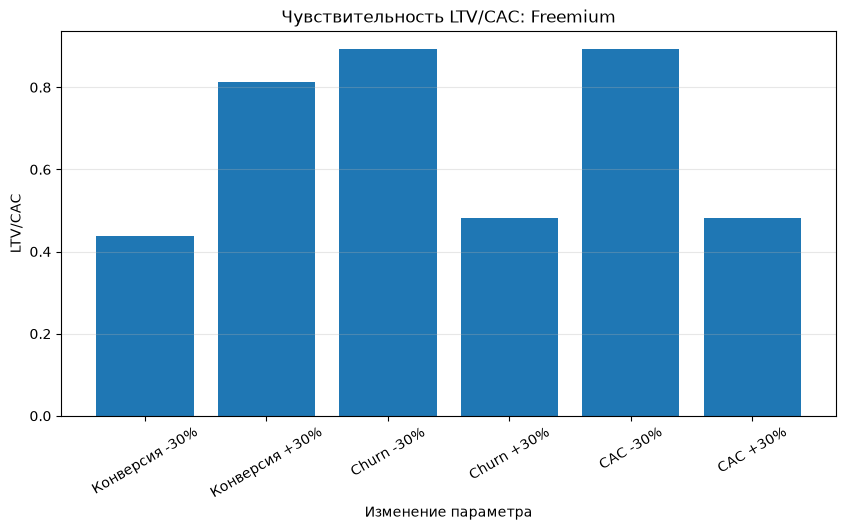

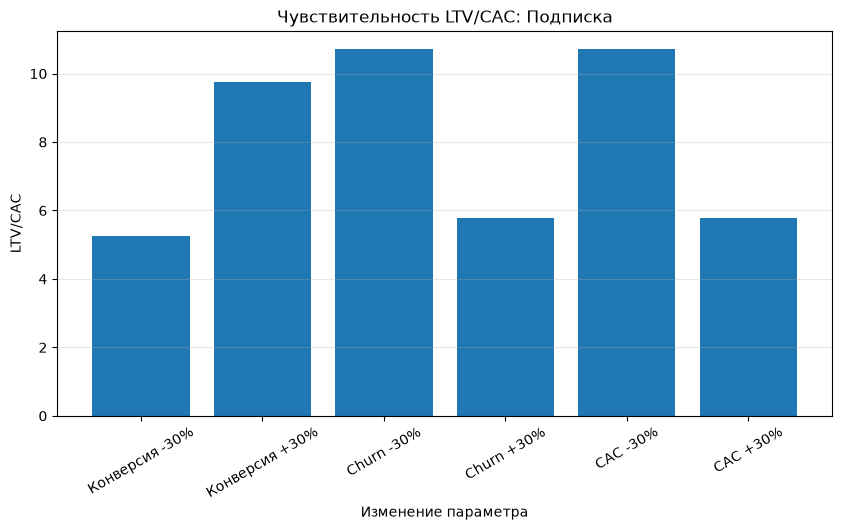

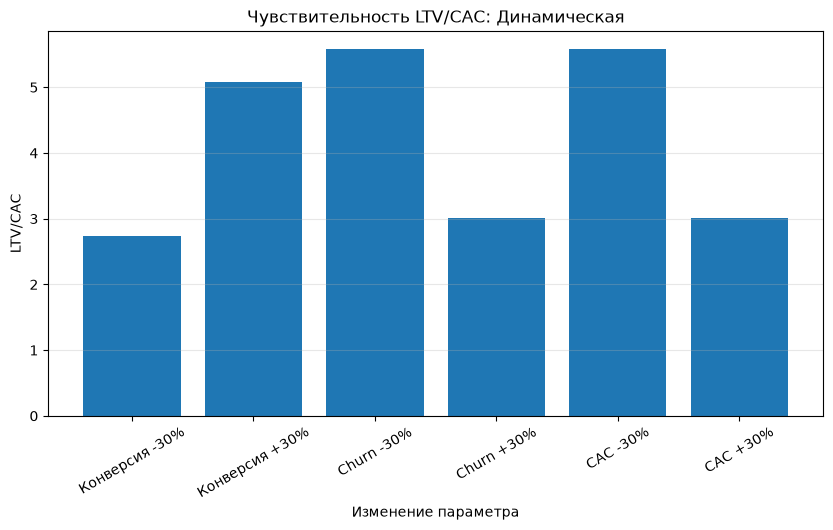

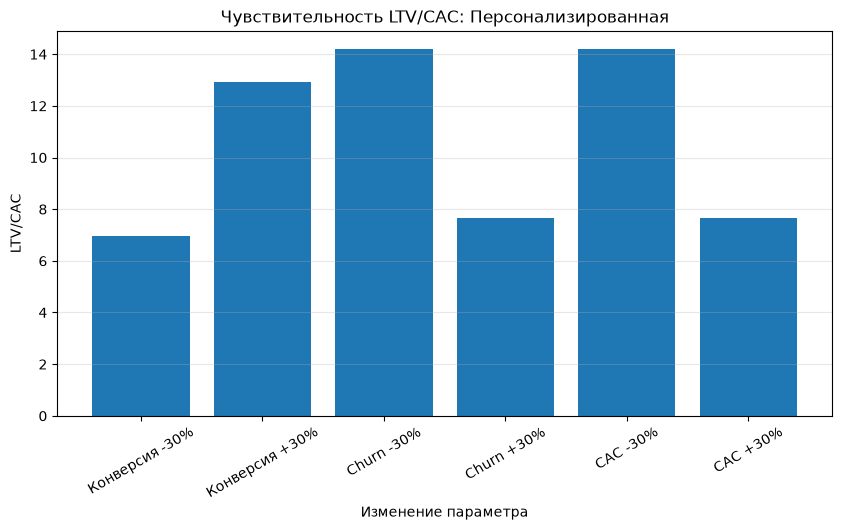

In [21]:
# Строим отдельный график для каждой стратегии

for strategy_name in strategies.keys():

    # Выбираем данные конкретной стратегии
    strategy_sensitivity = sensitivity_df[
        sensitivity_df["Стратегия"] == strategy_name
    ].copy()

    # Формируем название каждого сценария
    strategy_sensitivity["Сценарий"] = (
        strategy_sensitivity["Параметр"]
        + " "
        + strategy_sensitivity["Изменение"]
    )

    plt.figure(figsize=(10, 5))

    plt.bar(
        strategy_sensitivity["Сценарий"],
        strategy_sensitivity["LTV/CAC"]
    )

    plt.title(
        f"Чувствительность LTV/CAC: {strategy_name}"
    )
    plt.xlabel("Изменение параметра")
    plt.ylabel("LTV/CAC")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)

    plt.show()

## 17. Оценка доли потенциального рынка

Потенциальный российский рынок сервиса составляет 500 000 пользователей.

В соответствии с прогнозом к третьему году пользовательская база должна составить 3 600 пользователей.

Рассчитаем долю потенциального рынка:

$$
Market\ Share=
\frac{N_{users}}{N_{market}}\times100\%
$$

где:

- $N_{users}$ — количество пользователей сервиса;
- $N_{market}$ — потенциальный размер рынка.

In [22]:
# Размер потенциального рынка
market_size = 500_000

# Количество пользователей в 3-й год
year_3_users = users[3]

# Рассчитываем долю рынка
market_share = year_3_users / market_size * 100

print(
    f"Доля потенциального рынка в 3-й год: "
    f"{market_share:.2f}%"
)

Доля потенциального рынка в 3-й год: 0.72%


## 18. Итоговое сравнение стратегий по NPV

Для окончательного сравнения рассмотрим NPV каждой ценовой стратегии.

NPV учитывает:

- первоначальные затраты на разработку;
- годовую выручку;
- операционные расходы;
- затраты на привлечение пользователей;
- ставку дисконтирования.

Поэтому данный показатель позволяет оценить финансовый результат проекта на заданном горизонте в три года.

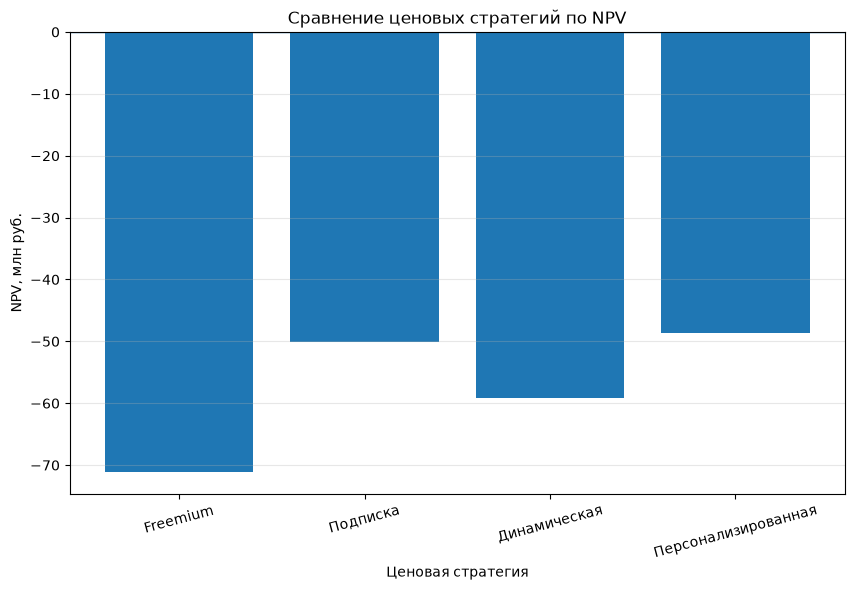

In [23]:
# Строим итоговый график NPV

plt.figure(figsize=(10, 6))

plt.bar(
    npv_df["Стратегия"],
    npv_df["NPV, руб."] / 1_000_000
)

# Линия безубыточности
plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Сравнение ценовых стратегий по NPV")
plt.xlabel("Ценовая стратегия")
plt.ylabel("NPV, млн руб.")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 19. Стратегическая рекомендация

На основании проведённых расчётов рассмотрим результаты по основным показателям.

Персонализированная стратегия показывает:

- ARPU — 318 руб./мес.;
- Lifetime — 25 месяцев;
- LTV — 7 950 руб.;
- LTV/CAC при среднем CAC — 9,94.

Это наиболее высокие значения среди рассмотренных стратегий.

Подписочная стратегия также показывает устойчивые показатели:

- ARPU — 300 руб./мес.;
- Lifetime — 20 месяцев;
- LTV — 6 000 руб.;
- LTV/CAC — 7,50.

Динамическая стратегия имеет промежуточные показатели.

Freemium показывает наиболее низкий ARPU и LTV/CAC, что связано прежде всего с низкой конверсией 2%.

С учётом рассчитанных показателей в качестве основного направления для дальнейшего тестирования целесообразно рассматривать **персонализированную стратегию**.

При этом отрицательный NPV показывает, что использовать текущую модель без дополнительных изменений нельзя считать достаточным основанием для масштабирования проекта. Необходимо сначала проверить возможность повышения конверсии, снижения Churn и оптимизации операционных расходов и CAC.

## 20. План реализации

Для внедрения персонализированной стратегии можно использовать поэтапный подход.

### Этап 1. Тестирование

Провести пилотное тестирование нескольких вариантов цены и определить реакцию пользователей.

Основные показатели:

- конверсия в платную версию;
- ARPU;
- Churn;
- количество активных пользователей.

### Этап 2. Анализ результатов

Сравнить фактические значения показателей с расчётными.

Особое внимание необходимо уделить взаимосвязи цены и конверсии: увеличение цены не должно приводить к настолько сильному снижению конверсии, чтобы итоговый ARPU уменьшался.

### Этап 3. Оптимизация привлечения

Сравнить каналы привлечения по CAC и постепенно увеличивать долю наиболее эффективных каналов.

### Этап 4. Оптимизация удержания

Проводить анализ причин ухода пользователей и снижать Churn за счёт повышения полезности сервиса, качества генерируемого контента и удобства работы.

### Этап 5. Масштабирование

После подтверждения устойчивой юнит-экономики увеличить объём привлечения пользователей и постепенно масштабировать сервис.

## 21. Основные KPI

Для контроля эффективности ценовой стратегии необходимо отслеживать следующие показатели:

| KPI | Что показывает |
|---|---|
| Conversion | Долю пользователей, перешедших в платную версию |
| Churn | Долю пользователей, которые прекращают использование сервиса |
| ARPU | Среднюю месячную выручку на одного пользователя |
| Lifetime | Среднюю продолжительность взаимодействия с клиентом |
| LTV | Совокупную ценность клиента |
| CAC | Стоимость привлечения одного клиента |
| LTV/CAC | Соотношение ценности клиента и стоимости его привлечения |
| NPV | Финансовый результат проекта с учётом дисконтирования |
| Количество пользователей | Масштаб пользовательской базы |
| Выручка | Денежный результат от работы сервиса |

Особое внимание следует уделять показателям LTV/CAC и NPV, поскольку они позволяют оценивать не только рост пользовательской базы, но и экономическую эффективность проекта.

## 22. Основные риски и способы их снижения

### Высокий CAC

Рост стоимости привлечения пользователей снижает показатель LTV/CAC.

**Способ снижения:** развивать контент-маркетинг, SEO и другие каналы с более низкой стоимостью привлечения.

### Высокий Churn

Рост Churn сокращает Lifetime и LTV.

**Способ снижения:** анализировать причины ухода пользователей и повышать полезность сервиса.

### Низкая конверсия

Низкая конверсия уменьшает ARPU и LTV.

**Способ снижения:** тестировать тарифы, ценностное предложение и ограничения бесплатной версии.

### Высокие операционные расходы

Затраты на поддержку и облачную инфраструктуру составляют 2 млн руб. в месяц и существенно влияют на финансовый результат.

**Способ снижения:** контролировать потребление вычислительных ресурсов и оптимизировать инфраструктуру.

### Отрицательный NPV

При текущих параметрах все стратегии имеют отрицательный NPV на горизонте трёх лет.

**Способ снижения:** увеличить выручку на пользователя, повысить эффективность привлечения, снизить операционные расходы и рассмотреть более длительный горизонт развития проекта.

# 23. Итоговый вывод

В работе были рассмотрены четыре стратегии ценообразования сервиса «AI-Копирайтер»: Freemium, подписочная, динамическая и персонализированная.

Для каждой стратегии были рассчитаны ARPU, Lifetime, LTV и LTV/CAC.

На основании расчётов установлено, что наиболее высокие значения ARPU, Lifetime и LTV имеет персонализированная стратегия:

$$
ARPU=318\text{ руб./мес.}
$$

$$
Lifetime=25\text{ месяцев}
$$

$$
LTV=7950\text{ руб.}
$$

При среднем CAC = 800 руб. показатель LTV/CAC составляет:

$$
LTV/CAC=\frac{7950}{800}=9{,}94
$$

Подписочная стратегия также показывает высокую эффективность привлечения: LTV/CAC составляет 7,50.

Для Freemium значение LTV/CAC при среднем CAC составляет только 0,63, что связано с низкой конверсией в платную версию.

Прогноз пользовательской базы показывает рост с 1 000 пользователей в нулевом году до 3 600 пользователей в третьем году.

Однако расчёт прибыли показывает, что при заданных операционных расходах в 2 млн руб. в месяц все стратегии остаются убыточными в течение рассматриваемых трёх лет.

Расчёт NPV с учётом первоначальных затрат на разработку 15 млн руб. также показывает отрицательный результат для всех стратегий:

| Стратегия | NPV, млн руб. |
|---|---:|
| Freemium | −71,10 |
| Подписка | −50,08 |
| Динамическая | −59,17 |
| Персонализированная | −48,62 |

Таким образом, исходные параметры проекта не обеспечивают окупаемость на трёхлетнем горизонте.

Для дальнейшего тестирования целесообразно рассматривать персонализированную стратегию, поскольку она показывает наиболее высокие показатели ARPU, Lifetime, LTV и LTV/CAC, а также наименьшее по модулю отрицательное значение NPV среди рассмотренных вариантов.

Перед масштабированием необходимо проверить расчётные предположения на реальных данных. В первую очередь следует контролировать конверсию, Churn, CAC, ARPU, LTV/CAC и операционные расходы.

Анализ чувствительности показывает, что улучшение конверсии, снижение Churn и снижение CAC способны существенно улучшить экономику сервиса. Поэтому именно эти параметры должны стать основными направлениями дальнейшей оптимизации проекта.